In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Pro_Solvers.pro_solvers import solve_heat, solve_heat2d, image_diff
from My_Solvers.pde_solvers import fdm, fdm2D, image_diff_an, image_diff_an_haar
#from medpy.filter.smoothing import anisotropic_diffusion
from skimage.util import random_noise
plt.rcParams["figure.figsize"] = (5, 3)  # width x height in inches
from skimage import data, io, img_as_float
from matplotlib.animation import FuncAnimation
import time
from scipy.interpolate import interp1d
#from manim import *
#from manim.utils.ipython_magic import ManimMagic
#get_ipython().register_magics(ManimMagic)

#%load_ext manim

num steps =4445
it took 2158.9902606010437 seconds
it took 123.4459719657898 seconds


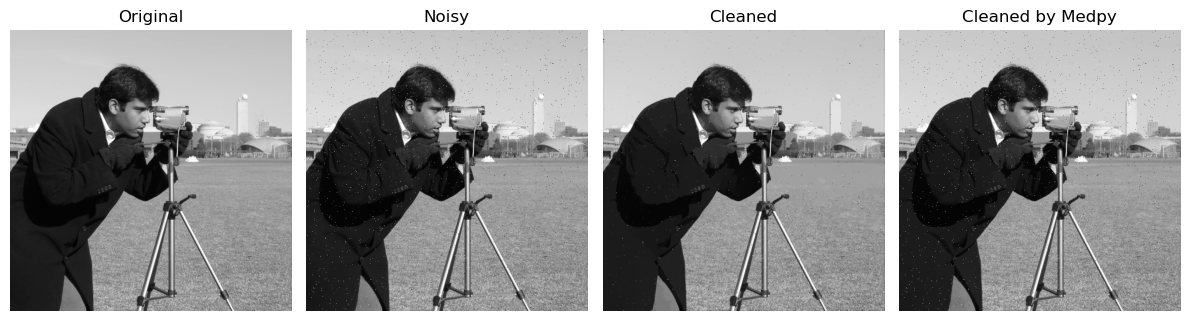

In [11]:
#original image 
img = data.camera()
#img = data.coins()
#img = data.microaneurysms()
#img = data.page()

#noisy image
img_noise = img.copy()
for row in range(img.shape[0]):
    for col in range(img.shape[1]):
        if np.random.randint(100) == 1:
            img_noise[row,col] = np.random.randint(255)

#"cleaned" image
alpha = 1
t_end = 1000
#pf = lambda x, k: np.exp(-x**2 / k**2)
tick = time.time()
img_cln = image_diff_an(img_noise, t_end = t_end, K = 1, l = .5)
tock = time.time()
print(f"it took {tock - tick} seconds")

img_cln_medpy = anisotropic_diffusion(img_noise, niter = 4000, kappa = 1, gamma = 0.2, option=1)
tick = time.time()
print(f"it took {tick - tock} seconds")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Noisy")
plt.imshow(img_noise, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Cleaned")
#r = (img[0,0] / img_cln[0,0])
r = 1
plt.imshow(r * img_cln, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Cleaned by Medpy")
#r = (img[0,0] / img_cln[0,0])
r = 1
plt.imshow(r * img_cln_medpy, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

It took 5.887348651885986 seconds


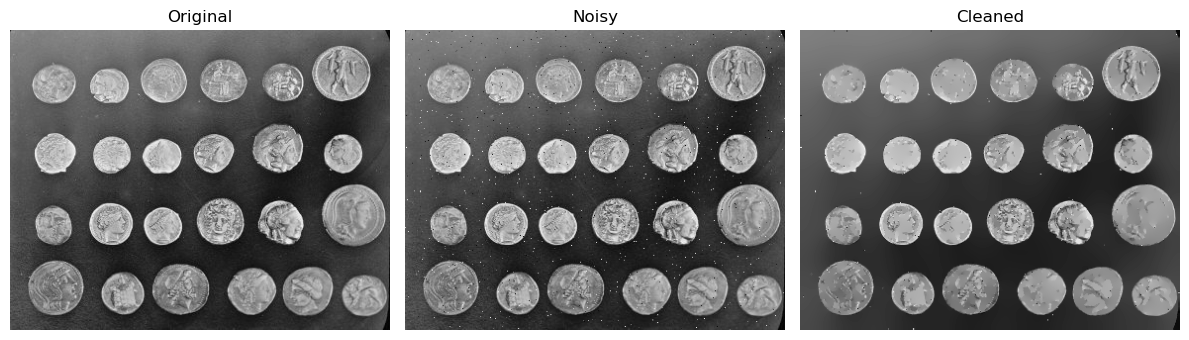

In [15]:
#original image 
#img = data.camera()
img = data.coins()
#img = data.microaneurysms()

#noisy image
img_noise = img.copy()
for row in range(img.shape[0]):
    for col in range(img.shape[1]):
        if np.random.randint(100) == 1:
            img_noise[row,col] = np.random.randint(255)

#"cleaned" image
alpha = 1
t_end = 100
tick = time.time()
img_cln = image_diff_an(img_noise, t_end = t_end, K = 10, l = .25)
tock = time.time()
print(f"It took {tock - tick} seconds")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(img_noise, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Cleaned")
plt.imshow(img_cln, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

num steps =356
it took 10.075793504714966


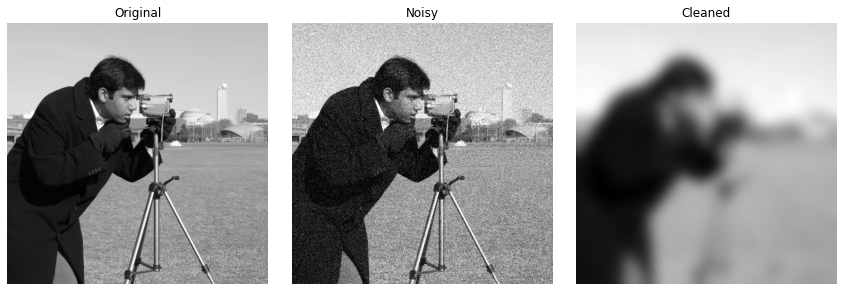

In [4]:
#original image 
img = data.camera()
#img = data.coins()
#img = data.microaneurysms()

img_noise = random_noise(img, mode='gaussian', mean=0, var=0.01)

# Clip to valid range [0, 1] if needed
#img_noise = np.clip(img_noise, 0, 1)

#noisy image
#img_noise = img.copy()
#for row in range(img.shape[0]):
#    for col in range(img.shape[1]):
#        if np.random.randint(100) == 1:
#            img_noise[row,col] = np.random.randint(255)

#"cleaned" image
alpha = 1
t_end = 80
pf = lambda x, k: np.exp(-x**2 / k**2)
tick = time.time()
img_cln = image_diff_an(img_noise, t_end = t_end, K = 1/100, l = .5, c = pf)
tock = time.time()
print(f"it took {tock-tick}")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(img_noise, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Cleaned")
#r = (img[0,0] / img_cln[0,0])
r = 1
plt.imshow(r * img_cln, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
img = data.camera()
x = np.linspace(0, 1, img.shape[0])
y = np.linspace(0, 1, img.shape[1])
X, Y = np.meshgrid(x, y)

A, H, C, W, img_cln = image_diff_an_haar(img)

num steps =9


(-0.5, 511.5, 511.5, -0.5)

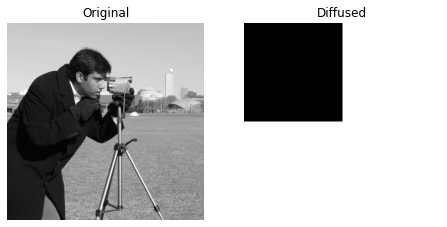

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Diffused")
plt.imshow(C, cmap='gray')
plt.axis('off')

In [32]:
C.shape

(9, 512, 512)

In [8]:
C[0]

array([0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741747,
       0.93741747, 0.93741747, 0.93741747, 0.93741747, 0.93741